# Day 59: Decision Tree — sklearn + Visualization
**Phase 4 · Machine Learning** | Dataset: FC Lahore Lions matches (synthetic, seed = 42)

## Objective
By the end of this notebook I should be able to:
- Fit a decision tree with sklearn (`.fit()`, `.predict()`, confusion matrix)
- **Visualize** an actual tree with `plot_tree(...)` and read a node
- Show the **overfitting demo**: fully grown tree vs `max_depth=3`, train vs test accuracy
- Read `feature_importances_` and explain what it does and does not tell us

## Imports

In [1]:
# numpy and pandas for data
import numpy as np
import pandas as pd

# matplotlib for charts and the tree diagram
import matplotlib.pyplot as plt

# the tree model, its plotting function, and evaluation tools
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score

plt.rcParams["axes.grid"] = True

## Theory
- **Recap (Day 58):** a tree splits on the feature with the highest information gain, node by node.
- **In sklearn**, `DecisionTreeClassifier()` does that automatically. No manual entropy math needed.
- **`plot_tree()`** draws the whole tree: each box (node) shows the split rule, the impurity, the sample count, and the class counts.
- **Overfitting:** with no depth limit, a tree keeps splitting until every leaf is pure (or almost). It can end up memorising noise in the training data.
  - `max_depth=None` (default): fully grown, very high train accuracy, weaker test accuracy.
  - `max_depth=3`: a shallower, simpler tree. Usually closer train and test accuracy.
- **`feature_importances_`**: for each feature, how much it reduced impurity across the whole tree, in total. Values sum to 1.
  - A feature can score 0 simply because the tree never needed it, not because it is useless on its own.
  - Importance is **specific to this tree**. A different depth or a different algorithm can rank features differently.

**Football picture:** a fully grown tree is a scout who writes a unique rule for every single match he has seen, even lucky ones. A shallow tree only keeps the rules that generalise, like "more shots on target usually means a win".

## Example 1: Fit, Predict and Confusion Matrix

In [2]:
# Synthetic data: 500 matches, several features, one 0/1 target
rng = np.random.default_rng(42)                      # seed = 42 so results repeat
n_matches = 500

shots = rng.integers(0, 13, size=n_matches)          # shots on target
possession = rng.integers(35, 66, size=n_matches)    # possession %
pass_accuracy = rng.integers(70, 93, size=n_matches) # pass accuracy %
home_game = rng.integers(0, 2, size=n_matches)       # 1 = home, 0 = away
opponent_rank = rng.integers(1, 21, size=n_matches)  # 1 = strongest opponent
kickoff_hour = rng.integers(12, 22, size=n_matches)  # 24-hour kickoff time (NOT linked to result)

# Hidden "real" win probability. kickoff_hour is left out on purpose (irrelevant feature).
z = (0.45 * shots + 0.04 * (possession - 50) + 0.7 * home_game
     + 0.10 * (opponent_rank - 10) - 3.0)
won = rng.binomial(1, 1 / (1 + np.exp(-z)))

df = pd.DataFrame({
    "match_id": np.arange(1, n_matches + 1),
    "shots_on_target": shots,
    "possession_pct": possession,
    "pass_accuracy_pct": pass_accuracy,
    "home_game": home_game,
    "opponent_rank": opponent_rank,
    "kickoff_hour": kickoff_hour,
    "won": won
})

# Save next to the notebook, then read it back
df.to_csv("day_59_fc_lahore_lions_matches.csv", index=False)
df = pd.read_csv("day_59_fc_lahore_lions_matches.csv")
print(df.head())
print("\nWin rate:", round(df["won"].mean(), 3))

   match_id  shots_on_target  possession_pct  pass_accuracy_pct  home_game  \
0         1                1              38                 88          1   
1         2               10              55                 86          0   
2         3                8              64                 82          0   
3         4                5              61                 90          0   
4         5                5              43                 72          1   

   opponent_rank  kickoff_hour  won  
0             18            18    0  
1              2            12    0  
2              8            19    1  
3             10            13    0  
4             16            12    0  

Win rate: 0.502


In [3]:
# Features (X) and target (y), then a stratified 75/25 split
X = df.drop(columns=["match_id", "won"])
y = df["won"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 375 | Test: 125


In [4]:
# Fit a small, easy-to-read tree first (max_depth=3), predict, and look at the confusion matrix
small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(X_train, y_train)

y_pred = small_tree.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(confusion_matrix(y_test, y_pred))

Test accuracy: 0.768
[[55  7]
 [22 41]]


## Example 2: Visualizing the Tree

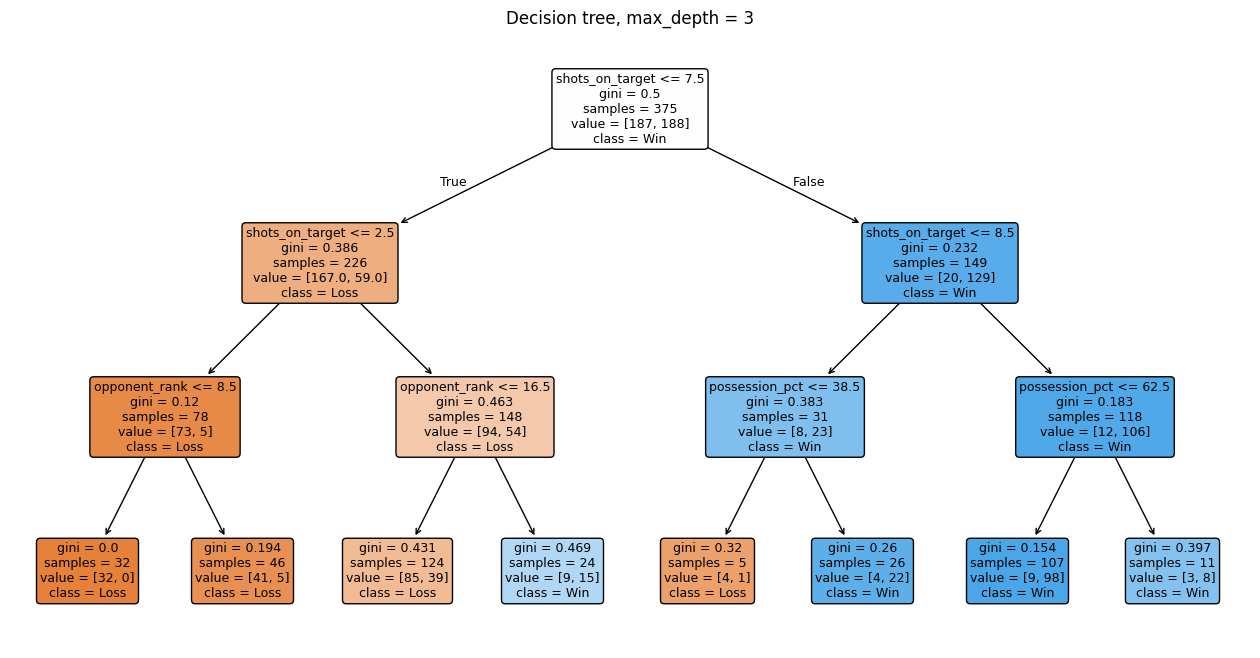

In [5]:
# Draw the max_depth=3 tree
plt.figure(figsize=(16, 8))
plot_tree(small_tree,
          feature_names=X.columns,
          class_names=["Loss", "Win"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision tree, max_depth = 3")
plt.savefig("images/tree_depth3.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Read the ROOT node by hand from the tree_ object
root_feature = X.columns[small_tree.tree_.feature[0]]
root_threshold = small_tree.tree_.threshold[0]
root_samples = small_tree.tree_.n_node_samples[0]
root_impurity = small_tree.tree_.impurity[0]

print("Root splits on:", root_feature, "<=", round(root_threshold, 2))
print("Samples at root:", root_samples, "| Gini impurity:", round(root_impurity, 3))

Root splits on: shots_on_target <= 7.5
Samples at root: 375 | Gini impurity: 0.5


## Example 3: Overfitting Demo

In [7]:
# Fully grown tree: no depth limit
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

print("Fully grown tree")
print("Depth:", full_tree.get_depth(), "| Leaves:", full_tree.get_n_leaves())
print("Train accuracy:", round(full_tree.score(X_train, y_train), 3))
print("Test accuracy: ", round(full_tree.score(X_test, y_test), 3))

Fully grown tree
Depth: 13 | Leaves: 84
Train accuracy: 1.0
Test accuracy:  0.672


In [8]:
print("max_depth = 3 tree")
print("Depth:", small_tree.get_depth(), "| Leaves:", small_tree.get_n_leaves())
print("Train accuracy:", round(small_tree.score(X_train, y_train), 3))
print("Test accuracy: ", round(small_tree.score(X_test, y_test), 3))

max_depth = 3 tree
Depth: 3 | Leaves: 8
Train accuracy: 0.813
Test accuracy:  0.768


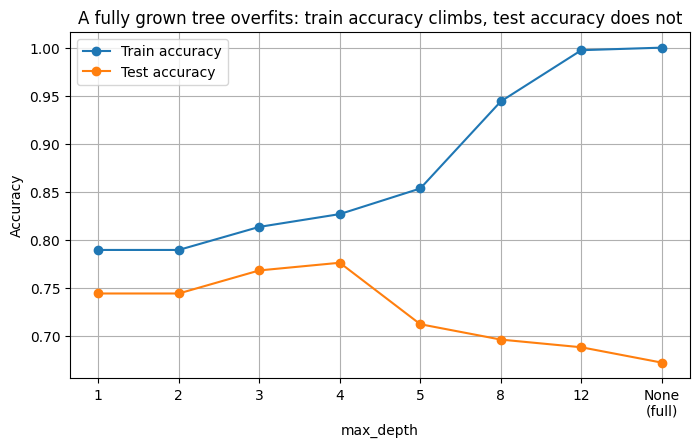

In [9]:
# Chart: train vs test accuracy across several depths
depths = [1, 2, 3, 4, 5, 8, 12, None]
train_scores, test_scores = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(m.score(X_train, y_train))
    test_scores.append(m.score(X_test, y_test))

labels = [str(d) if d is not None else "None\n(full)" for d in depths]
x_pos = range(len(depths))

plt.figure(figsize=(8, 4.5))
plt.plot(x_pos, train_scores, marker="o", label="Train accuracy")
plt.plot(x_pos, test_scores, marker="o", label="Test accuracy")
plt.xticks(x_pos, labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("A fully grown tree overfits: train accuracy climbs, test accuracy does not")
plt.legend()
plt.savefig("images/overfitting_depth.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Cross-validation across depths (Day 57 pattern), so the depth choice is not test-set guessing
print("depth | mean CV accuracy")
for d in [1, 2, 3, 4, 5, 8, None]:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    score = cross_val_score(m, X_train, y_train, cv=5).mean()
    print(f"{str(d):>5} | {score:.3f}")

depth | mean CV accuracy
    1 | 0.789
    2 | 0.784
    3 | 0.773
    4 | 0.779
    5 | 0.736
    8 | 0.709
 None | 0.731


## Example 4: Feature Importances

In [11]:
# Which features did the max_depth=3 tree actually use?
importances = pd.Series(small_tree.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
print(importances.round(3))

shots_on_target      0.899
opponent_rank        0.051
possession_pct       0.050
pass_accuracy_pct    0.000
home_game            0.000
kickoff_hour         0.000
dtype: float64


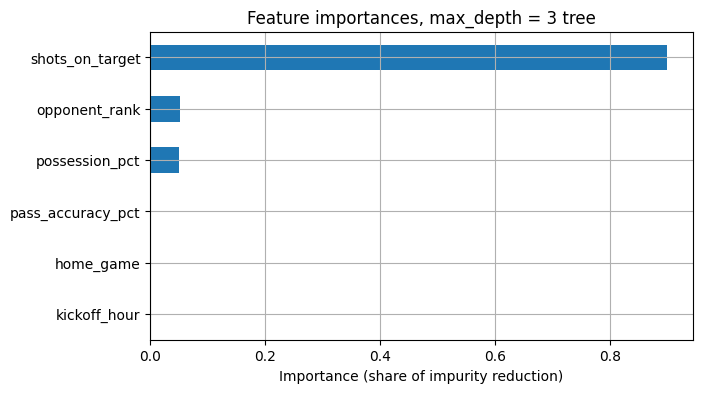

In [12]:
# Chart: feature importances as a bar chart
plt.figure(figsize=(7, 4))
importances.plot(kind="barh", color="tab:blue")
plt.gca().invert_yaxis()
plt.xlabel("Importance (share of impurity reduction)")
plt.title("Feature importances, max_depth = 3 tree")
plt.savefig("images/feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Compare with the FULLY GROWN tree - importances can shift once a tree can use more features
full_importances = pd.Series(full_tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print(full_importances.round(3))

# kickoff_hour was built to be irrelevant. Check its importance in both trees.
print("\nkickoff_hour importance -> depth 3:", round(importances["kickoff_hour"], 3),
      "| full tree:", round(full_importances["kickoff_hour"], 3))

shots_on_target      0.484
possession_pct       0.145
opponent_rank        0.144
pass_accuracy_pct    0.133
kickoff_hour         0.057
home_game            0.037
dtype: float64

kickoff_hour importance -> depth 3: 0.0 | full tree: 0.057


## Practice Exercise
**Your turn (Practice).** Using `X_train`, `y_train`, `X_test`, `y_test` already in this notebook:
1. Fit a tree with `max_depth=2`.
2. Print its test accuracy and its `feature_importances_`.
3. Compare the top feature to the `max_depth=3` tree's top feature.

In [14]:
# Your attempt here

In [15]:
# Worked answer
tree2 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree2.fit(X_train, y_train)

print("Test accuracy:", round(tree2.score(X_test, y_test), 3))
imp2 = pd.Series(tree2.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp2.round(3))
print("\nTop feature is the same as max_depth=3:", imp2.index[0] == importances.index[0])

Test accuracy: 0.744
shots_on_target      1.0
possession_pct       0.0
pass_accuracy_pct    0.0
home_game            0.0
opponent_rank        0.0
kickoff_hour         0.0
dtype: float64

Top feature is the same as max_depth=3: True


## Mini Challenge
**Find the best depth honestly.** Loop `max_depth` from 1 to 15 (plus `None`) using **5-fold CV on the training set** (Day 57 pattern), pick the depth with the highest mean CV accuracy, retrain on the full training set with that depth, and report the test accuracy plus feature importances.

In [16]:
# Mini Challenge solution
candidate_depths = list(range(1, 16)) + [None]
cv_means = []
for d in candidate_depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    cv_means.append(cross_val_score(m, X_train, y_train, cv=5).mean())

best_idx = int(np.argmax(cv_means))
best_depth = candidate_depths[best_idx]
print("Best depth by CV:", best_depth, "| mean CV accuracy:", round(cv_means[best_idx], 3))

final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_tree.fit(X_train, y_train)
print("Test accuracy:", round(final_tree.score(X_test, y_test), 3))

final_importances = pd.Series(final_tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print(final_importances.round(3))

Best depth by CV: 1 | mean CV accuracy: 0.789
Test accuracy: 0.744
shots_on_target      1.0
possession_pct       0.0
pass_accuracy_pct    0.0
home_game            0.0
opponent_rank        0.0
kickoff_hour         0.0
dtype: float64


## Summary
- `DecisionTreeClassifier().fit().predict()` works exactly like the other sklearn models from Days 55 and 57.
- `plot_tree()` shows the real split rules, impurity and sample counts, which is a great way to explain a model to non-technical people.
- A **fully grown tree** hit train accuracy 1.0 but a much lower test accuracy (0.672). **`max_depth=3`** gave lower train accuracy (0.813) but a *higher* test accuracy (0.768), a clear overfitting example.
- 5-fold CV over depths 1 to 15 (and unlimited) picked **depth = 1** as the strongest, mean CV accuracy 0.789. On this dataset, `shots_on_target` alone carries almost all the signal, so a single split (a "stump") generalises better than a deeper tree.
- **`feature_importances_`** showed `shots_on_target` dominating in every tree size, and the deliberately irrelevant `kickoff_hour` scored 0 in the shallow trees, only entering the fully grown tree (importance 0.057) once it had room to fit noise.
- **Next: Day 60 — Random Forest: ensemble and bagging theory.**